# Combinatorial background, ROI-blinded

Clean final notebook for the double-blip combinatorial-background check.

Policy encoded here:

- observed doublet candidates are read through the public blinding mask;
- the singles pool is not ROI-blinded and is used to build the data-driven doublet MC;
- the singles-driven MC receives the same circular ROI exclusion only for mask modes where the observed doublet sample is ROI-excluded (`signal` and `signal+background`);
- there is no sideband normalization and no normalization to the observed doublet count;
- the absolute expected doublet count is normalized from the single-blip occupancy, approximately \(N_{2} = N_{1}^{2}/(2N_{m events})\), times pair-selection and ROI keep fractions.

This notebook supports both the older event-group format and Hong Cai's newer flat `normal_hits` format.


## 0. Configuration

In [1]:
# Configuration

import numpy as np
import h5py
import matplotlib.pyplot as plt
import scipy.stats
import os
import re
import json
import math
from pathlib import Path

try:
    from tqdm.auto import tqdm
    TQDM_OK = True
except Exception:
    TQDM_OK = False

# Input data file. Supported formats:
#   old format:  /events/<event_key>/{labels,x,y,z,...}
#   Hong format: /normal_hits/data + /normal_hits/ref_region
DATA_H5 = "normal_hits_ref_region_data.h5"

# Public mask produced by make_doublet_blinding_mask_axis_symmetric.py or
# make_doublet_blinding_mask_axis_symmetric_hong_format.py.
BLINDING_MASK_H5 = "blinding_hc_signal.h5"
USE_PUBLIC_BLINDING = True
STRICT_BLINDING_MASK = True

# Main doublet selection.
MIN_DIST_CM = 10.0

# Accepted synthetic doublets to draw from the single-blip pool.
# Increase for smoother MC shapes; decrease for quick tests.
SINGLES_MC_TARGET = 200_000
SINGLES_MC_SEED = 10

# Apply the circular ROI cut to the singles-driven MC when the mask mode calls for it.
# This is auto-disabled for mode="background" and mode="nop".
APPLY_ROI_TO_SINGLES_MC = True

# Figure output.
OUTPUT_DIR = Path("double_blip_figures")
SAVE_FIGURES = True
FIG_DPI = 180

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Analysis input: {DATA_H5}")
print(f"Public blinding mask: {BLINDING_MASK_H5 if USE_PUBLIC_BLINDING else 'disabled'}")
print(f"Figures will be saved to: {OUTPUT_DIR.resolve()}")

_FIG_SAVE_COUNTER = {"n": 0}

def _slugify(text):
    text = str(text)
    text = re.sub(r"\$+", "", text)
    text = re.sub(r"[^A-Za-z0-9._-]+", "_", text).strip("._")
    return text or "figure"

def save_current_figure(name, fig=None, dpi=FIG_DPI, close=False):
    if not SAVE_FIGURES:
        return None
    _FIG_SAVE_COUNTER["n"] += 1
    stem = f"{_FIG_SAVE_COUNTER['n']:03d}_{_slugify(name)}"
    out = OUTPUT_DIR / f"{stem}.png"
    if fig is None:
        fig = plt.gcf()
    fig.savefig(out, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {out}")
    if close:
        plt.close(fig)
    return out


Analysis input: normal_hits_ref_region_data.h5
Public blinding mask: blinding_hc_signal.h5
Figures will be saved to: /home/bruno/combinatoryBg/blinding/double_blip_figures


## 1. Input loaders

This cell supports both the old event-group format and Hong Cai's flat `normal_hits` format.

In [2]:
# Input-format loaders and event summary helpers

SINGLE_ENERGY_KEYS = [
    "energy", "E", "adc", "adcs", "q", "Q", "charge", "charges", "dq", "de", "nhit", "nhits"
]

def fiducial_geom_mask_from_arrays(x, y, z):
    return (
        (y >= -51.85) & (y <= 51.85) &
        (((z >= 12.68) & (z <= 54.32)) | ((z >= -54.32) & (z <= -12.68)))
    )


def infer_cluster_energy(event_group, cluster_indices, candidate_keys=SINGLE_ENERGY_KEYS):
    """
    Best-effort cluster energy / charge estimator.

    Returns the sum over the first charge-like dataset found in the event group.
    If nothing suitable is present, returns np.nan.
    """
    n_points = len(event_group["x"])

    for key in candidate_keys:
        if key not in event_group:
            continue

        arr = event_group[key][:]
        arr = np.asarray(arr)

        # Per-point quantity: sum over hits in the cluster
        if arr.ndim == 1 and len(arr) == n_points:
            try:
                return float(np.nansum(arr[cluster_indices]))
            except Exception:
                pass

        # Already one value per event / cluster-like array — not safe to assume mapping here
        # so we skip it rather than risk a wrong interpretation.

    return np.nan


def _event_time_from_group(group):
    """
    Try to recover an event time / integration window from the group.
    This is only a helper; returning None is perfectly fine.
    """
    attr_candidates = [
        "event_window_s", "window_s", "readout_window_s", "dt_s",
        "duration_s", "livetime_s", "trigger_window_s"
    ]
    for k in attr_candidates:
        if k in group.attrs:
            try:
                return float(group.attrs[k])
            except Exception:
                pass
    return None


def _h5_path_exists(h5, path):
    try:
        h5[path]
        return True
    except KeyError:
        return False


def _dataset_names(ds):
    names = ds.dtype.names
    if names is None:
        raise TypeError(f"Dataset {ds.name} is not a compound/structured dataset.")
    return tuple(names)


def _resolve_field(names, requested, candidates, *, required=True, role="field"):
    """
    Resolve a structured-array field name.

    requested can be:
      - "auto" / None: pick the first available candidate
      - explicit field name
    """
    if requested is not None and requested != "auto":
        if requested not in names:
            raise KeyError(f"Requested {role} {requested!r} not found. Available fields: {names}")
        return requested

    for c in candidates:
        if c in names:
            return c

    if required:
        raise KeyError(f"Could not auto-detect {role}. Tried {candidates}. Available fields: {names}")
    return None


def _first_int_from_struct_array(arr, field):
    if field is None or arr is None or len(arr) == 0:
        return None
    try:
        vals = np.asarray(arr[field])
    except Exception:
        return None
    vals = vals.reshape(-1)
    if vals.size == 0:
        return None
    try:
        return int(vals[0])
    except Exception:
        return None


def _stringify_event_key_value(value):
    """Match the blinding script's string handling for integer/string/bytes event IDs."""
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="replace")
    try:
        # numpy bytes scalars do not always satisfy isinstance(value, bytes)
        if np.issubdtype(type(value), np.bytes_):
            return bytes(value).decode("utf-8", errors="replace")
    except Exception:
        pass
    return str(value)


def _event_key_from_hong_sources(event_index, hits, ref_row, *, event_id_field_hits=None, event_id_field_ref=None):
    """
    Match the event_key convention used by the Hong-format blinding script:
    prefer event_id from ref_region, then event_id from normal_hits/data, then ref index.
    """
    if event_id_field_ref is not None and ref_row is not None:
        try:
            return _stringify_event_key_value(ref_row[event_id_field_ref])
        except Exception:
            pass

    if event_id_field_hits is not None and hits is not None and len(hits) > 0:
        try:
            vals = np.asarray(hits[event_id_field_hits])
            if vals.size:
                return _stringify_event_key_value(vals.reshape(-1)[0])
        except Exception:
            pass

    return str(event_index)


def _trigger_policy_from_mask(mask_h5_path=None):
    """
    Use the public blinding mask config to choose which trigger types belong in the
    singles pool and observed-candidate bookkeeping.

    The blinding mask script modes mean:
      nop               -> all triggers
      background        -> only background_trigger_value
      signal            -> only signal_trigger_value
      signal+background -> all triggers, with ROI applied to doublets
    """
    policy = {
        "mode": "nop",
        "signal_trigger_value": 1,
        "background_trigger_value": 0,
        "use_trigger_filter": False,
        "allowed_trigger_values": None,
    }

    if mask_h5_path is None:
        return policy

    try:
        with h5py.File(mask_h5_path, "r") as f:
            raw = f["blinding"].attrs.get("config_json", "{}")
    except Exception:
        return policy

    if isinstance(raw, bytes):
        raw = raw.decode("utf-8", errors="replace")

    try:
        cfg = json.loads(str(raw))
    except Exception:
        cfg = {}

    mode = str(cfg.get("mode", "nop"))
    sig = int(cfg.get("signal_trigger_value", 1))
    bkg = int(cfg.get("background_trigger_value", 0))

    policy.update({
        "mode": mode,
        "signal_trigger_value": sig,
        "background_trigger_value": bkg,
    })

    if mode == "background":
        policy["use_trigger_filter"] = True
        policy["allowed_trigger_values"] = {bkg}
    elif mode == "signal":
        policy["use_trigger_filter"] = True
        policy["allowed_trigger_values"] = {sig}
    elif mode in {"signal+background", "nop"}:
        policy["use_trigger_filter"] = False
        policy["allowed_trigger_values"] = None
    else:
        print(f"Warning: unknown blinding mask mode {mode!r}; not applying trigger filtering to singles.")

    return policy


def _trigger_allowed(trigger_type, policy):
    if not policy.get("use_trigger_filter", False):
        return True
    return int(trigger_type) in set(policy["allowed_trigger_values"])


def _summarize_one_event_hits(
    *,
    hits,
    event_key,
    event_index,
    trigger_type,
    use_centroid=True,
    x_field="x",
    y_field="y",
    z_field="z",
    label_field="cluster_id",
    energy_field=None,
):
    """
    Convert one event's hit/blip rows into accepted fiducial clusters.
    Returns a list of cluster dicts.
    """
    if hits is None or len(hits) == 0:
        return []

    x = np.asarray(hits[x_field], dtype=float)
    y = np.asarray(hits[y_field], dtype=float)
    z = np.asarray(hits[z_field], dtype=float)
    labels = np.asarray(hits[label_field])

    geom_mask = fiducial_geom_mask_from_arrays(x, y, z)
    idx = np.where(geom_mask & (labels >= 0))[0]
    if idx.size == 0:
        return []

    labs = labels[idx]
    uniq = np.unique(labs)
    clusters = []

    for lab in uniq:
        cidx = idx[labs == lab]
        if cidx.size == 0:
            continue

        if use_centroid:
            pos = np.array([x[cidx].mean(), y[cidx].mean(), z[cidx].mean()], dtype=float)
        else:
            pos = np.array([x[cidx[0]], y[cidx[0]], z[cidx[0]]], dtype=float)

        if energy_field is not None and energy_field in hits.dtype.names:
            try:
                energy = float(np.nansum(np.asarray(hits[energy_field])[cidx]))
            except Exception:
                energy = np.nan
        else:
            energy = np.nan

        clusters.append({
            "event_key": str(event_key),
            "event_index": int(event_index),
            "trigger_type": int(trigger_type) if trigger_type is not None else -1,
            "label": int(lab),
            "npts": int(cidx.size),
            "x": float(pos[0]),
            "y": float(pos[1]),
            "z": float(pos[2]),
            "energy": float(energy) if np.isfinite(energy) else np.nan,
        })

    return clusters


def load_cluster_event_summary(
    h5_path,
    use_centroid=True,
    *,
    mask_h5_path=None,
    input_format="auto",
    hits_dataset="normal_hits/data",
    ref_region_dataset="normal_hits/ref_region",
    events_group="events",
    x_field="auto",
    y_field="auto",
    z_field="auto",
    label_field="auto",
    event_id_field="auto",
    trigger_type_field="auto",
):
    """
    Parse the clustering file and summarize accepted fiducial clusters.

    Supports two input layouts:

      1. Hong flat format:
           /normal_hits/data       structured array of blips/hits
           /normal_hits/ref_region event start/stop slices

      2. Older event-group format:
           /events/<event_key>/{labels,x,y,z,...}

    If mask_h5_path is provided and the mask config has mode="signal" or
    mode="background", the singles pool and event bookkeeping are filtered to
    the same trigger class as the public observed-doublet mask.
    """
    multiplicities = []
    singles = []
    doublets = []
    triplets = []
    all_clusters = []
    event_windows_s = []

    policy = _trigger_policy_from_mask(mask_h5_path)
    source_info = {}

    with h5py.File(h5_path, "r") as f:
        if input_format == "auto":
            if hits_dataset in f and ref_region_dataset in f:
                input_format_used = "normal-hits"
            elif events_group in f:
                input_format_used = "event-groups"
            elif hits_dataset in f:
                input_format_used = "normal-hits"
            else:
                raise KeyError(
                    "Could not auto-detect input format. Expected either "
                    f"{hits_dataset!r} (+ optional {ref_region_dataset!r}) or group {events_group!r}."
                )
        else:
            input_format_used = input_format

        if input_format_used == "normal-hits":
            if hits_dataset not in f:
                raise KeyError(f"Input HDF5 has no dataset {hits_dataset!r}.")

            hits_all = f[hits_dataset]
            hit_names = _dataset_names(hits_all)

            x_field_res = _resolve_field(hit_names, x_field, ["x", "X"], role="x field")
            y_field_res = _resolve_field(hit_names, y_field, ["y", "Y"], role="y field")
            z_field_res = _resolve_field(hit_names, z_field, ["z", "Z"], role="z field")
            label_field_res = _resolve_field(
                hit_names,
                label_field,
                ["cluster_id", "cluster", "label", "labels", "dbscan_label"],
                role="cluster/label field",
            )
            event_id_field_hits = _resolve_field(
                hit_names,
                event_id_field,
                ["event_id", "event", "evt_id", "event_idx", "event_index", "entry", "spill_id"],
                required=False,
                role="event id field in hits",
            )
            trigger_field_hits = _resolve_field(
                hit_names,
                trigger_type_field,
                ["beam_type", "trigger_type", "is_beam", "beam_related", "beam", "trigger"],
                required=False,
                role="trigger/beam type field in hits",
            )
            energy_field = _resolve_field(
                hit_names,
                "auto",
                SINGLE_ENERGY_KEYS,
                required=False,
                role="energy/charge field",
            )

            has_ref = ref_region_dataset in f
            if has_ref:
                ref = f[ref_region_dataset]
                ref_names = _dataset_names(ref)
                if "start" not in ref_names or "stop" not in ref_names:
                    raise KeyError(f"{ref_region_dataset!r} must have 'start' and 'stop' fields.")

                event_id_field_ref = _resolve_field(
                    ref_names,
                    event_id_field,
                    ["event_id", "event", "evt_id", "event_idx", "event_index", "entry", "spill_id"],
                    required=False,
                    role="event id field in ref_region",
                )
                trigger_field_ref = _resolve_field(
                    ref_names,
                    trigger_type_field,
                    ["beam_type", "trigger_type", "is_beam", "beam_related", "beam", "trigger"],
                    required=False,
                    role="trigger/beam type field in ref_region",
                )

                iterable = range(len(ref))
                iterable = tqdm(iterable, desc=f"Summarizing {Path(h5_path).name}") if TQDM_OK else iterable

                for event_index, rr in enumerate(iterable):
                    # tqdm yields the index when iterable is range(...); recover row explicitly.
                    rr_row = ref[int(rr)]
                    start = int(rr_row["start"])
                    stop = int(rr_row["stop"])

                    if stop <= start:
                        # Empty event still counts if trigger selection is not excluding it.
                        multiplicities.append(0)
                        continue

                    hits = hits_all[start:stop]
                    event_key = _event_key_from_hong_sources(
                        int(rr),
                        hits,
                        rr_row,
                        event_id_field_hits=event_id_field_hits,
                        event_id_field_ref=event_id_field_ref,
                    )

                    trigger_type = _first_int_from_struct_array(hits, trigger_field_hits)
                    if trigger_type is None:
                        trigger_type = _first_int_from_struct_array(
                            np.asarray([rr_row], dtype=ref.dtype),
                            trigger_field_ref,
                        )
                    if trigger_type is None:
                        trigger_type = -1

                    if not _trigger_allowed(trigger_type, policy):
                        continue

                    clusters = _summarize_one_event_hits(
                        hits=hits,
                        event_key=event_key,
                        event_index=int(rr),
                        trigger_type=trigger_type,
                        use_centroid=use_centroid,
                        x_field=x_field_res,
                        y_field=y_field_res,
                        z_field=z_field_res,
                        label_field=label_field_res,
                        energy_field=energy_field,
                    )

                    multiplicities.append(len(clusters))
                    all_clusters.extend(clusters)
                    if len(clusters) == 1:
                        singles.append(clusters[0])
                    elif len(clusters) == 2:
                        doublets.append(clusters)
                    elif len(clusters) == 3:
                        triplets.append(clusters)

            else:
                if event_id_field_hits is None:
                    raise KeyError(
                        f"No {ref_region_dataset!r} dataset found and no event-id field could be auto-detected "
                        f"in {hits_dataset!r}. Provide an event_id field or ref_region dataset."
                    )

                event_ids = np.asarray(hits_all[event_id_field_hits])
                unique_events = np.unique(event_ids)
                iterable = unique_events
                iterable = tqdm(iterable, desc=f"Summarizing {Path(h5_path).name}") if TQDM_OK else iterable

                for event_index, event_value in enumerate(iterable):
                    row_idx = np.where(event_ids == event_value)[0]
                    if row_idx.size == 0:
                        continue

                    hits = hits_all[row_idx]
                    event_key = str(event_value)
                    trigger_type = _first_int_from_struct_array(hits, trigger_field_hits)
                    if trigger_type is None:
                        trigger_type = -1

                    if not _trigger_allowed(trigger_type, policy):
                        continue

                    clusters = _summarize_one_event_hits(
                        hits=hits,
                        event_key=event_key,
                        event_index=int(event_index),
                        trigger_type=trigger_type,
                        use_centroid=use_centroid,
                        x_field=x_field_res,
                        y_field=y_field_res,
                        z_field=z_field_res,
                        label_field=label_field_res,
                        energy_field=energy_field,
                    )

                    multiplicities.append(len(clusters))
                    all_clusters.extend(clusters)
                    if len(clusters) == 1:
                        singles.append(clusters[0])
                    elif len(clusters) == 2:
                        doublets.append(clusters)
                    elif len(clusters) == 3:
                        triplets.append(clusters)

            source_info = {
                "input_format": "normal-hits",
                "hits_dataset": hits_dataset,
                "ref_region_dataset": ref_region_dataset if has_ref else None,
                "x_field": x_field_res,
                "y_field": y_field_res,
                "z_field": z_field_res,
                "label_field": label_field_res,
                "event_id_field_hits": event_id_field_hits,
                "trigger_field_hits": trigger_field_hits,
                "energy_field": energy_field,
                "trigger_policy": policy,
            }

        elif input_format_used == "event-groups":
            events = f[events_group]
            keys = list(events.keys())
            iterable = tqdm(keys, desc=f"Summarizing {Path(h5_path).name}") if TQDM_OK else keys

            for event_index, key in enumerate(iterable):
                g = events[key]
                labels = np.asarray(g["labels"][:])
                x = np.asarray(g["x"][:], dtype=float)
                y = np.asarray(g["y"][:], dtype=float)
                z = np.asarray(g["z"][:], dtype=float)

                geom_mask = fiducial_geom_mask_from_arrays(x, y, z)
                idx = np.where(geom_mask & (labels >= 0))[0]
                event_time = _event_time_from_group(g)
                if event_time is not None:
                    event_windows_s.append(event_time)

                if idx.size == 0:
                    multiplicities.append(0)
                    continue

                labs = labels[idx]
                uniq = np.unique(labs)
                clusters = []
                for lab in uniq:
                    cidx = idx[labs == lab]
                    if cidx.size == 0:
                        continue

                    if use_centroid:
                        pos = np.array([x[cidx].mean(), y[cidx].mean(), z[cidx].mean()], dtype=float)
                    else:
                        pos = np.array([x[cidx[0]], y[cidx[0]], z[cidx[0]]], dtype=float)

                    energy = infer_cluster_energy(g, cidx)
                    cluster = {
                        "event_key": str(key),
                        "event_index": int(event_index),
                        "trigger_type": -1,
                        "label": int(lab),
                        "npts": int(cidx.size),
                        "x": float(pos[0]),
                        "y": float(pos[1]),
                        "z": float(pos[2]),
                        "energy": float(energy) if np.isfinite(energy) else np.nan,
                    }
                    clusters.append(cluster)
                    all_clusters.append(cluster)

                multiplicities.append(len(clusters))
                if len(clusters) == 1:
                    singles.append(clusters[0])
                elif len(clusters) == 2:
                    doublets.append(clusters)
                elif len(clusters) == 3:
                    triplets.append(clusters)

            source_info = {
                "input_format": "event-groups",
                "events_group": events_group,
                "trigger_policy": policy,
            }

        else:
            raise ValueError(f"Unsupported input_format: {input_format_used!r}")

    return {
        "multiplicities": np.asarray(multiplicities, dtype=int),
        "singles": singles,
        "doublets": doublets,
        "triplets": triplets,
        "all_clusters": all_clusters,
        "event_windows_s": np.asarray(event_windows_s, dtype=float),
        "source_info": source_info,
    }

## 2. Blinding, MC, normalization, and plotting helpers

In [3]:
# Statistical helpers

def chi2_ndf_pvalue_from_hists(
    data_counts,
    model_counts,
    n_fit_params=0,
    min_variance=1.0,
    variance="model",
):
    """
    Binned Pearson chi2.

    Parameters
    ----------
    data_counts : array-like
        Observed bin counts.
    model_counts : array-like
        Expected/model bin counts, already normalized as desired.
    n_fit_params : int
        Parameters/constraints to subtract from NDF. For a shape-only
        comparison normalized to the observed total, use n_fit_params=1.
    min_variance : float
        Variance floor for numerical stability.
    variance : {"model", "data", "model+data"}
        Which variance prescription to use. For a fixed expected model,
        "model" is the usual Pearson choice. The old notebook used "data",
        which can badly over-penalize bins where data are small.
    """
    data_counts = np.asarray(data_counts, dtype=float)
    model_counts = np.asarray(model_counts, dtype=float)

    mask = (data_counts > 0) | (model_counts > 0)
    if not np.any(mask):
        return np.nan, 0, np.nan, mask

    d = data_counts[mask]
    m = model_counts[mask]

    if variance == "data":
        var = d
    elif variance == "model":
        var = m
    elif variance == "model+data":
        var = m + d
    else:
        raise ValueError("variance must be one of: 'model', 'data', 'model+data'")

    var = np.maximum(var, float(min_variance))

    chi2 = float(np.sum((d - m)**2 / var))
    ndf = int(mask.sum() - n_fit_params)
    if ndf <= 0:
        return chi2, ndf, np.nan, mask

    pval = float(scipy.stats.chi2.sf(chi2, ndf))
    return chi2, ndf, pval, mask


def poisson_deviance_gof_from_hists(data_counts, model_counts, n_fit_params=0):
    """
    Poisson likelihood-ratio/deviance goodness-of-fit for absolute count predictions.

    This is usually more stable than Pearson chi2 for sparse bins. It still tests
    the absolute singles-normalized rate, so it can be large even when the plotted
    *shape* looks good.
    """
    d = np.asarray(data_counts, dtype=float)
    m = np.asarray(model_counts, dtype=float)

    mask = (d > 0) | (m > 0)
    if not np.any(mask):
        return np.nan, 0, np.nan, mask

    d = d[mask]
    m = m[mask]

    # If expected is zero but data is nonzero, the likelihood-ratio statistic is infinite.
    bad = (m <= 0) & (d > 0)
    if np.any(bad):
        return np.inf, int(mask.sum() - n_fit_params), 0.0, mask

    positive = d > 0
    term = np.zeros_like(d, dtype=float)
    term[positive] = d[positive] * np.log(d[positive] / m[positive])
    dev = float(2.0 * np.sum(m - d + term))

    ndf = int(mask.sum() - n_fit_params)
    if ndf <= 0:
        return dev, ndf, np.nan, mask

    pval = float(scipy.stats.chi2.sf(dev, ndf))
    return dev, ndf, pval, mask


def _pvalue_text(chi2, ndf, pval):
    """Human-readable p-value, including underflow-safe log10(p)."""
    if not np.isfinite(chi2) or ndf <= 0 or not np.isfinite(pval):
        return "p = n/a"
    if pval == 0.0:
        try:
            log10p = scipy.stats.chi2.logsf(chi2, ndf) / np.log(10.0)
            if np.isfinite(log10p):
                return fr"$\log_{{10}} p = {log10p:.1f}$"
        except Exception:
            pass
        return r"$p < 10^{-300}$"
    return fr"$p = {pval:.3g}$"


def _stats_label(chi2, ndf, pval, prefix=r"$\chi^2$"):
    if not np.isfinite(chi2) or ndf <= 0 or not np.isfinite(pval):
        return f"{prefix}/ndf = n/a, p = n/a"
    return fr"{prefix}/ndf = {chi2:.1f}/{ndf} = {chi2/ndf:.2f},  {_pvalue_text(chi2, ndf, pval)}"


# Public blinding, doublet, MC-normalization, and default plotting helpers

# Cell 7.2b — public circular-ROI blinding helpers

def _decode_h5_string_array(arr):
    out = []
    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8", errors="replace"))
        else:
            out.append(str(x))
    return np.asarray(out, dtype=object)


def load_public_blinding_mask(mask_h5_path):
    """
    Load the public candidate-level circular-ROI blinding mask.

    Expected structure:
        /blinding/event_key
        /blinding/mask

    Expected mask fields:
        candidate_id, event_index, blind_mask, visible

    The mask hides observed doublet candidates in the hard ROI. The config_json
    attribute stores the same circular ROI definition used by the mask script;
    this notebook reuses that config to apply the same ROI exclusion to the
    singles-driven MC doublet distribution.
    """
    mask_h5_path = Path(mask_h5_path)
    if not mask_h5_path.exists():
        raise FileNotFoundError(
            f"Public blinding mask not found: {mask_h5_path}\n"
            "Create it with the hard-ROI blinding script, or set USE_PUBLIC_BLINDING=False "
            "only for deliberate unblinded/debug work."
        )

    with h5py.File(mask_h5_path, "r") as f:
        g = f["blinding"]
        event_keys = _decode_h5_string_array(g["event_key"][:])
        mask = g["mask"][:]
        attrs = dict(g.attrs)

    visible = np.asarray(mask["visible"], dtype=bool)
    blind_mask = np.asarray(mask["blind_mask"], dtype=bool)
    candidate_id = np.asarray(mask["candidate_id"], dtype=int)

    if len(event_keys) != len(visible):
        raise ValueError("Public blinding mask has mismatched event_key and mask lengths.")

    visible_by_event_key = {}
    blind_by_event_key = {}

    for k, vis, blind in zip(event_keys, visible, blind_mask):
        k = str(k)
        if k in visible_by_event_key:
            raise ValueError(f"Duplicate event_key in blinding mask: {k}")
        visible_by_event_key[k] = bool(vis)
        blind_by_event_key[k] = bool(blind)

    cfg = {}
    if "config_json" in attrs:
        raw = attrs["config_json"]
        if isinstance(raw, bytes):
            raw = raw.decode("utf-8", errors="replace")
        cfg = json.loads(str(raw))

    return {
        "event_key": event_keys,
        "candidate_id": candidate_id,
        "visible": visible,
        "blind_mask": blind_mask,
        "visible_by_event_key": visible_by_event_key,
        "blind_by_event_key": blind_by_event_key,
        "attrs": attrs,
        "config": cfg,
    }


def circular_roi_config_from_public_mask(mask_h5_path):
    """Extract the circular projected-angle ROI settings from a public mask file."""
    public = load_public_blinding_mask(mask_h5_path)
    cfg = public.get("config", {})

    # Support both the newer hard-ROI names and a few older names from earlier prototypes.
    theta_radius_deg = cfg.get("theta_radius_deg", cfg.get("theta_cone_deg", None))
    if theta_radius_deg is None:
        raise KeyError(
            "Could not find theta_radius_deg/theta_cone_deg in mask config_json. "
            "Regenerate the mask with the hard circular-ROI blinding script."
        )

    return {
        "theta_radius_deg": float(theta_radius_deg),
        "center_zx_deg": float(cfg.get("center_zx_deg", 0.0)),
        "center_zy_deg": float(cfg.get("center_zy_deg", 0.0)),
        "axis_symmetric_roi": bool(cfg.get("axis_symmetric_roi", True)),
    }


def blinding_mode_from_public_mask(mask_h5_path):
    """
    Return the public mask mode.

    New Hong-format masks include mode explicitly:
      nop, background, signal, signal+background.

    Older hard-ROI-only masks did not store a mode. For those, assume the
    old behavior: ROI applies to all observed doublet candidates, equivalent
    to signal+background for ROI purposes.
    """
    public = load_public_blinding_mask(mask_h5_path)
    cfg = public.get("config", {})
    if "mode" in cfg:
        return str(cfg.get("mode"))
    if ("theta_radius_deg" in cfg) or ("theta_cone_deg" in cfg):
        return "signal+background"
    return "nop"


def roi_applies_for_mode(mode):
    """Whether the circular ROI should be applied to synthetic doublet MC."""
    return str(mode) in {"signal", "signal+background"}


def select_doublet_arrays(obs, selection):
    """Apply a boolean selection to every per-candidate array in an obs_doublets dict."""
    selection = np.asarray(selection, dtype=bool)
    out = {}

    for k, v in obs.items():
        arr = np.asarray(v)
        if arr.shape[0] == selection.shape[0]:
            out[k] = arr[selection]
        else:
            out[k] = v

    return out


def _angle_delta(a, center):
    """Smallest signed angular difference a - center, wrapped to [-pi, pi)."""
    a = np.asarray(a, dtype=float)
    return (a - center + np.pi) % (2.0 * np.pi) - np.pi


def axis_symmetric_projected_angles(dx, dy, dz, *, axis_symmetric=True):
    """
    Projected angles used by the hard circular ROI.

    If axis_symmetric=True, the doublet is treated as an axis rather than a directed
    arrow, so +z and -z aligned pairs are both considered signal-like.
    """
    dx = np.asarray(dx, dtype=float)
    dy = np.asarray(dy, dtype=float)
    dz = np.asarray(dz, dtype=float)

    if axis_symmetric:
        flip = dz < 0
        dx = np.where(flip, -dx, dx)
        dy = np.where(flip, -dy, dy)
        dz = np.abs(dz)

    theta_zx = np.arctan2(dx, dz)
    theta_zy = np.arctan2(dy, dz)
    return theta_zx, theta_zy


def circular_roi_mask_for_doublet_arrays(
    obs,
    *,
    theta_radius_deg,
    center_zx_deg=0.0,
    center_zy_deg=0.0,
    axis_symmetric=True,
):
    """
    Return True for doublets inside the circular projected-angle ROI.
    """
    theta_zx, theta_zy = axis_symmetric_projected_angles(
        obs["dx"], obs["dy"], obs["dz"], axis_symmetric=axis_symmetric
    )
    d_zx = _angle_delta(theta_zx, np.deg2rad(center_zx_deg))
    d_zy = _angle_delta(theta_zy, np.deg2rad(center_zy_deg))
    radius = np.sqrt(d_zx * d_zx + d_zy * d_zy)
    return radius <= np.deg2rad(theta_radius_deg)


def apply_circular_roi_exclusion_to_doublet_arrays(
    obs,
    *,
    theta_radius_deg,
    center_zx_deg=0.0,
    center_zy_deg=0.0,
    axis_symmetric=True,
    label="sample",
    use_public_blinding=True,
):
    """
    Apply the hard circular ROI exclusion to an arbitrary doublet-array dict.

    This is used for the singles-driven MC. It does not need event_key; it simply
    applies the same angular ROI definition stored in the observed-data mask file.
    """
    if not use_public_blinding:
        print(f"{label}: ROI exclusion disabled.")
        return obs, np.ones(len(obs["dx"]), dtype=bool)

    in_roi = circular_roi_mask_for_doublet_arrays(
        obs,
        theta_radius_deg=theta_radius_deg,
        center_zx_deg=center_zx_deg,
        center_zy_deg=center_zy_deg,
        axis_symmetric=axis_symmetric,
    )
    keep = ~in_roi
    out = select_doublet_arrays(obs, keep)
    print(f"{label}: circular ROI exclusion applied.")
    return out, keep


def build_doublet_arrays_from_cluster_pairs(cluster_pairs, min_dist=10.0, sort_by_z=True):
    """
    Build per-candidate arrays from event-level two-cluster pairs.

    Important: this stores `event_key`, which is the join key used by the
    public blinding mask for observed doublets.
    """
    event_key = []
    dx, dy, dz = [], [], []
    theta_z, theta_zx, theta_zy = [], [], []
    e0, e1, esum, eabsdiff = [], [], [], []
    npts0, npts1 = [], []

    for c0, c1 in cluster_pairs:
        p0 = np.array([c0["x"], c0["y"], c0["z"]], dtype=float)
        p1 = np.array([c1["x"], c1["y"], c1["z"]], dtype=float)

        if sort_by_z and (p1[2] < p0[2]):
            p0, p1 = p1, p0
            c0, c1 = c1, c0

        d = p1 - p0
        dist = np.linalg.norm(d)
        if dist < float(min_dist):
            continue

        dx.append(d[0])
        dy.append(d[1])
        dz.append(d[2])

        theta_z.append(np.arccos(np.clip(d[2] / dist, -1.0, 1.0)))
        theta_zx.append(np.arctan2(d[0], d[2]))
        theta_zy.append(np.arctan2(d[1], d[2]))

        ee0 = c0.get("energy", np.nan)
        ee1 = c1.get("energy", np.nan)

        e0.append(ee0)
        e1.append(ee1)
        esum.append(ee0 + ee1 if np.isfinite(ee0) and np.isfinite(ee1) else np.nan)
        eabsdiff.append(abs(ee1 - ee0) if np.isfinite(ee0) and np.isfinite(ee1) else np.nan)

        npts0.append(c0.get("npts", np.nan))
        npts1.append(c1.get("npts", np.nan))
        event_key.append(str(c0["event_key"]))

    return {
        "event_key": np.asarray(event_key, dtype=object),
        "dx": np.asarray(dx, dtype=float),
        "dy": np.asarray(dy, dtype=float),
        "dz": np.asarray(dz, dtype=float),
        "theta_z": np.asarray(theta_z, dtype=float),
        "theta_zx": np.asarray(theta_zx, dtype=float),
        "theta_zy": np.asarray(theta_zy, dtype=float),
        "e0": np.asarray(e0, dtype=float),
        "e1": np.asarray(e1, dtype=float),
        "esum": np.asarray(esum, dtype=float),
        "eabsdiff": np.asarray(eabsdiff, dtype=float),
        "npts0": np.asarray(npts0, dtype=float),
        "npts1": np.asarray(npts1, dtype=float),
    }


def apply_public_blinding_to_doublet_arrays(
    obs,
    mask_h5_path=None,
    *,
    label="sample",
    strict=True,
    use_public_blinding=True,
):
    """
    Keep only observed candidates marked visible in the public blinding mask.

    This is only for observed doublet candidates, where event_key is meaningful.
    Synthetic singles-driven MC doublets are blinded with
    apply_circular_roi_exclusion_to_doublet_arrays(...).
    """
    if (not use_public_blinding) or (mask_h5_path is None):
        print(f"{label}: public blinding disabled.")
        return obs

    public = load_public_blinding_mask(mask_h5_path)

    if "event_key" not in obs:
        raise KeyError("obs doublet arrays do not contain event_key. Re-run the helper cell above.")

    keys = np.asarray(obs["event_key"]).astype(str)
    visible = np.zeros(len(keys), dtype=bool)
    missing = []

    for i, key in enumerate(keys):
        if key not in public["visible_by_event_key"]:
            missing.append(key)
            # Non-strict mode keeps missing entries visible to avoid silent data loss.
            visible[i] = True
        else:
            visible[i] = public["visible_by_event_key"][key]

    if missing and strict:
        raise RuntimeError(
            f"{label}: {len(missing)} post-min_dist doublets are missing from the public mask. "
            "This usually means the mask was made with different min_dist/use_centroid/fiducial settings. "
            f"Example missing key: {missing[0]}"
        )

    out = select_doublet_arrays(obs, visible)

    print(f"{label}: public candidate mask applied.")
    if missing:
        print(f"  warning: {len(missing)} candidates were missing from the mask and kept visible because strict=False")

    return out


def monte_carlo_doublets_from_singles(
    single_clusters,
    n_accept=100_000,
    min_dist=10.0,
    sort_by_z=True,
    seed=1234,
    allow_same_source_event=True,
    max_trials_factor=50,
    return_metadata=False,
):
    """
    Build synthetic doublets by independently drawing from the observed single-cluster pool.

    When return_metadata=True, also return trial/acceptance metadata so the MC can
    be normalized from the single-blip pool rather than from observed doublet sidebands.
    """
    rng = np.random.default_rng(seed)
    singles = list(single_clusters)
    if len(singles) < 2:
        raise ValueError("Need at least two single clusters to build a singles-driven MC.")

    accepted_pairs = []
    trials = 0
    max_trials = int(max_trials_factor * n_accept)

    while len(accepted_pairs) < n_accept and trials < max_trials:
        trials += 1
        i0 = rng.integers(0, len(singles))
        i1 = rng.integers(0, len(singles) - 1)
        if i1 >= i0:
            i1 += 1
        c0 = singles[i0]
        c1 = singles[i1]

        if (not allow_same_source_event) and (c0["event_key"] == c1["event_key"]):
            continue

        p0 = np.array([c0["x"], c0["y"], c0["z"]], dtype=float)
        p1 = np.array([c1["x"], c1["y"], c1["z"]], dtype=float)
        if np.linalg.norm(p1 - p0) < float(min_dist):
            continue

        accepted_pairs.append((c0, c1))

    if len(accepted_pairs) < n_accept:
        print(f"Warning: requested {n_accept} accepted singles-MC doublets, got {len(accepted_pairs)}")

    arrays = build_doublet_arrays_from_cluster_pairs(accepted_pairs, min_dist=min_dist, sort_by_z=sort_by_z)

    meta = {
        "n_requested_accept": int(n_accept),
        "n_trials": int(trials),
        "n_accepted_min_dist": int(len(accepted_pairs)),
        "min_dist_acceptance": float(len(accepted_pairs) / trials) if trials > 0 else np.nan,
        "allow_same_source_event": bool(allow_same_source_event),
        "seed": int(seed),
        "max_trials": int(max_trials),
    }

    if return_metadata:
        return arrays, meta
    return arrays


def expected_doublets_from_singles(summary, singles_mc_meta, *, roi_keep_fraction=1.0):
    """
    Estimate the expected number of accepted combinatorial doublets from the single-blip pool.

    The normalization uses only:
      - number of analyzed event windows
      - number of observed single-blip events
      - min-distance acceptance from the singles-driven MC
      - ROI keep fraction from applying the same blinding ROI to the MC

    It does NOT use observed doublet counts or sideband normalization.

    For low occupancy, lambda ~= N_single / N_events and
        N_doublet ~= N_events * lambda^2 / 2.
    """
    n_events = int(len(summary["multiplicities"]))
    n_single = int(len(summary["singles"]))

    if n_events <= 0:
        raise ValueError("No events found in summary.")

    lam_from_singles = n_single / n_events
    n_doublet_before_pair_cuts = 0.5 * n_events * lam_from_singles * lam_from_singles

    min_dist_acceptance = float(singles_mc_meta.get("min_dist_acceptance", np.nan))
    if not np.isfinite(min_dist_acceptance):
        min_dist_acceptance = 1.0

    expected_after_min_dist = n_doublet_before_pair_cuts * min_dist_acceptance
    expected_after_roi = expected_after_min_dist * float(roi_keep_fraction)

    return {
        "n_events": n_events,
        "n_single": n_single,
        "lambda_from_singles": float(lam_from_singles),
        "n_doublet_before_pair_cuts": float(n_doublet_before_pair_cuts),
        "min_dist_acceptance": float(min_dist_acceptance),
        "roi_keep_fraction": float(roi_keep_fraction),
        "expected_after_min_dist": float(expected_after_min_dist),
        "expected_after_roi": float(expected_after_roi),
    }


def _model_counts_from_expected_total(counts_model_raw, expected_total=None):
    """
    Convert MC histogram counts into expected model bin counts.

    If expected_total is provided, scale by the singles-based expected total.
    If not, return raw MC counts. This function deliberately does not normalize
    MC to the observed doublet sideband count.
    """
    counts_model_raw = np.asarray(counts_model_raw, dtype=float)
    if expected_total is None:
        return counts_model_raw
    total = counts_model_raw.sum()
    if total <= 0:
        return counts_model_raw
    return counts_model_raw * (float(expected_total) / total)


def _shape_model_counts_from_mc(data_counts, counts_model_raw):
    """
    Convert raw MC histogram counts into expected counts for a *shape-only*
    goodness-of-fit test, conditioned on the observed data total.

    This is a diagnostic only; it is not used to normalize the physics
    background prediction. The final rate prediction remains singles-based.
    """
    data_total = float(np.sum(data_counts))
    return _model_counts_from_expected_total(counts_model_raw, data_total)


def shape_gof_from_hists(data_counts, counts_model_raw):
    """
    Shape-only Pearson chi2: MC shape normalized to the observed total.

    This answers: "Do the shapes agree, ignoring the overall rate?"
    It subtracts one NDF for the total-count constraint.
    """
    model_shape = _shape_model_counts_from_mc(data_counts, counts_model_raw)
    return chi2_ndf_pvalue_from_hists(
        data_counts,
        model_shape,
        n_fit_params=1,
        variance="model",
    )


def absolute_gof_from_hists(data_counts, counts_model_raw, expected_total):
    """
    Absolute-rate Poisson deviance using the singles-based expected total.

    This answers: "Does the singles-normalized absolute prediction agree?"
    It can be poor even when the shapes look excellent.
    """
    model_abs = _model_counts_from_expected_total(counts_model_raw, expected_total)
    return poisson_deviance_gof_from_hists(data_counts, model_abs, n_fit_params=0)



def overlay_hist_simple(
    data_a, data_b, label_a, label_b, title, xlabel,
    bins=60, density=True, range=None, annotate_stats=True,
    model_expected_total=None,
):
    """
    Overlay data and singles-driven MC histograms.

    Important distinction:
      - The plotted density overlay is a shape comparison.
      - The shape chi2 is conditional on the observed total count; this is a
        diagnostic and is NOT used for the physics normalization.
      - If model_expected_total is provided, an absolute-rate Poisson deviance is
        printed separately using the singles-based expected normalization.
    """
    a = np.asarray(data_a)
    b = np.asarray(data_b)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if len(a) == 0 or len(b) == 0:
        print(f"Skipping {title}: one of the inputs is empty.")
        return

    if range is None:
        allv = np.concatenate([a, b])
        range = (float(np.min(allv)), float(np.max(allv)))

    counts_a, edges = np.histogram(a, bins=bins, range=range)
    counts_b, _ = np.histogram(b, bins=edges)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    # Shape-only diagnostic: condition on the observed total.
    chi2_shape, ndf_shape, p_shape, _ = shape_gof_from_hists(counts_a, counts_b)
    stats = _stats_label(chi2_shape, ndf_shape, p_shape, prefix=r"$\chi^2_{\rm shape}$")

    # Absolute-rate diagnostic: use singles-based expected total, but do not use
    # this for the density overlay because that would visually hide the shape.
    abs_stats = None
    if model_expected_total is not None:
        dev_abs, ndf_abs, p_abs, _ = absolute_gof_from_hists(counts_a, counts_b, model_expected_total)
        abs_stats = _stats_label(dev_abs, ndf_abs, p_abs, prefix=r"$D_{\rm Pois,abs}$")

    if density:
        norm_a = max(len(a), 1) * widths
        y_a = counts_a / norm_a
        yerr_a = np.sqrt(counts_a) / norm_a
        ylabel = "normalized counts"
    else:
        # In count mode, draw the absolute singles-normalized prediction when available.
        y_a = counts_a.astype(float)
        yerr_a = np.sqrt(counts_a)
        ylabel = "counts"

    plt.figure(figsize=(7, 5))
    plt.errorbar(
        centers, y_a, yerr=yerr_a, fmt="o", markersize=4, capsize=2,
        label=f"{label_a} | {stats}"
    )

    if density:
        plt.hist(
            b, bins=edges, density=True, histtype="step", linewidth=2,
            linestyle="--", label=label_b
        )
    else:
        if model_expected_total is not None:
            model_b = _model_counts_from_expected_total(counts_b, model_expected_total)
        else:
            model_b = _shape_model_counts_from_mc(counts_a, counts_b)
        plt.step(edges[:-1], model_b, where="post", linestyle="--", linewidth=2, label=label_b)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(fontsize=9)
    plt.tight_layout()
    save_current_figure(title)
    plt.show()

    print(f"{title}")
    print(f"  shape-only diagnostic: {stats}")
    if abs_stats is not None:
        print(f"  absolute singles-normalized diagnostic: {abs_stats}")
        print(f"  singles-based expected total = {float(model_expected_total):.3g}")
        print("  note: a poor absolute diagnostic with a good shape diagnostic usually means")
        print("        the total-rate model, not the distribution shape, is disagreeing.")




# Final overrides / plotting helpers

def monte_carlo_doublets_from_singles(
    single_clusters,
    n_accept=100_000,
    min_dist=10.0,
    sort_by_z=True,
    seed=1234,
    allow_same_source_event=True,
    max_trials_factor=50,
    return_metadata=False,
):
    """
    Build synthetic doublets by independently drawing from the observed single-cluster pool.

    The accepted sample enforces the same minimum-distance cut as the observed doublets.
    The returned metadata gives the pair-level min-distance acceptance used for the
    singles-based normalization. The acceptance is computed after any same-source
    rejection, so it describes the probability that an eligible pair passes min_dist.
    """
    rng = np.random.default_rng(seed)
    singles = list(single_clusters)
    if len(singles) < 2:
        raise ValueError("Need at least two single clusters to build a singles-driven MC.")

    accepted_pairs = []
    trials_total = 0
    trials_pair_tested = 0
    same_source_rejects = 0
    min_dist_rejects = 0
    max_trials = int(max_trials_factor * n_accept)

    while len(accepted_pairs) < n_accept and trials_total < max_trials:
        trials_total += 1
        i0 = rng.integers(0, len(singles))
        i1 = rng.integers(0, len(singles) - 1)
        if i1 >= i0:
            i1 += 1

        c0 = singles[i0]
        c1 = singles[i1]

        if (not allow_same_source_event) and (c0["event_key"] == c1["event_key"]):
            same_source_rejects += 1
            continue

        trials_pair_tested += 1

        p0 = np.array([c0["x"], c0["y"], c0["z"]], dtype=float)
        p1 = np.array([c1["x"], c1["y"], c1["z"]], dtype=float)
        if np.linalg.norm(p1 - p0) < float(min_dist):
            min_dist_rejects += 1
            continue

        accepted_pairs.append((c0, c1))

    if len(accepted_pairs) < n_accept:
        print(f"Warning: requested {n_accept} accepted singles-MC doublets, got {len(accepted_pairs)}")

    arrays = build_doublet_arrays_from_cluster_pairs(accepted_pairs, min_dist=min_dist, sort_by_z=sort_by_z)

    meta = {
        "n_requested_accept": int(n_accept),
        "n_trials_total": int(trials_total),
        "n_trials_pair_tested": int(trials_pair_tested),
        "n_same_source_rejects": int(same_source_rejects),
        "n_min_dist_rejects": int(min_dist_rejects),
        "n_accepted_min_dist": int(len(accepted_pairs)),
        "min_dist_acceptance": float(len(accepted_pairs) / trials_pair_tested) if trials_pair_tested > 0 else np.nan,
        "allow_same_source_event": bool(allow_same_source_event),
        "seed": int(seed),
        "max_trials": int(max_trials),
    }

    if return_metadata:
        return arrays, meta
    return arrays


def overlay_hist_simple(
    data_a, data_b, label_a, label_b, title, xlabel,
    bins=60, density=True, range=None, annotate_stats=True,
    model_expected_total=None,
    yscale=None,
):
    """
    Overlay observed doublets and singles-driven MC.

    The plotted density overlay is shape-only. The shape chi2 normalizes the MC
    shape to the observed total only for the diagnostic. If model_expected_total
    is provided, an absolute-rate Poisson deviance is printed separately using
    the singles-based normalization.
    """
    a = np.asarray(data_a)
    b = np.asarray(data_b)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if len(a) == 0 or len(b) == 0:
        print(f"Skipping {title}: one of the inputs is empty.")
        return

    if range is None and not np.ndim(bins):
        allv = np.concatenate([a, b])
        range = (float(np.min(allv)), float(np.max(allv)))

    counts_a, edges = np.histogram(a, bins=bins, range=range)
    counts_b, _ = np.histogram(b, bins=edges)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    chi2_shape, ndf_shape, p_shape, _ = shape_gof_from_hists(counts_a, counts_b)
    stats = _stats_label(chi2_shape, ndf_shape, p_shape, prefix=r"$\chi^2_{\rm shape}$")

    abs_stats = None
    if model_expected_total is not None:
        dev_abs, ndf_abs, p_abs, _ = absolute_gof_from_hists(counts_a, counts_b, model_expected_total)
        abs_stats = _stats_label(dev_abs, ndf_abs, p_abs, prefix=r"$D_{\rm Pois,abs}$")

    fig, ax = plt.subplots(figsize=(7, 5))

    if density:
        norm_a = max(len(a), 1) * widths
        y_a = counts_a / norm_a
        yerr_a = np.sqrt(counts_a) / norm_a
        ylabel = "normalized counts"
        ax.errorbar(
            centers, y_a, yerr=yerr_a, fmt="o", markersize=4, capsize=2,
            label=f"{label_a} | {stats}"
        )
        ax.hist(
            b, bins=edges, density=True, histtype="step", linewidth=2,
            linestyle="--", label=label_b
        )
    else:
        y_a = counts_a.astype(float)
        yerr_a = np.sqrt(counts_a)
        ylabel = "counts"
        ax.errorbar(
            centers, y_a, yerr=yerr_a, fmt="o", markersize=4, capsize=2,
            label=f"{label_a} | {stats}"
        )
        if model_expected_total is not None:
            model_b = _model_counts_from_expected_total(counts_b, model_expected_total)
        else:
            model_b = _shape_model_counts_from_mc(counts_a, counts_b)
        ax.step(edges[:-1], model_b, where="post", linestyle="--", linewidth=2, label=label_b)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if yscale is not None:
        ax.set_yscale(yscale)
        if yscale == "log":
            ax.set_ylim(bottom=max(ax.get_ylim()[0], 1e-6))
    ax.legend(fontsize=9)
    fig.tight_layout()
    save_current_figure(title, fig=fig)
    plt.show()

    print(f"{title}")
    print(f"  shape-only diagnostic: {stats}")
    if abs_stats is not None:
        print(f"  absolute singles-normalized diagnostic: {abs_stats}")
        print(f"  singles-based expected total = {float(model_expected_total):.3g}")


def integer_sum_bins(*arrays):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr)
        arr = arr[np.isfinite(arr)]
        if len(arr):
            vals.append(arr)
    if not vals:
        return np.arange(-0.5, 1.5, 1.0)
    allv = np.concatenate(vals).astype(int)
    lo = int(np.min(allv))
    hi = int(np.max(allv))
    return np.arange(lo - 0.5, hi + 1.5, 1.0)


def projected_angles_deg_for_plot(obs, roi_cfg):
    theta_zx, theta_zy = axis_symmetric_projected_angles(
        obs["dx"], obs["dy"], obs["dz"],
        axis_symmetric=roi_cfg["axis_symmetric_roi"],
    )
    return np.degrees(theta_zx), np.degrees(theta_zy)


def plot_circular_roi_diagnostic(obs_doublets, singles_mc, roi_cfg, *, blinding_mode, roi_applies_to_singles_mc):
    """2D projected-angle diagnostic showing the circular ROI."""
    roi_note = "ROI applied" if roi_applies_to_singles_mc else f"ROI not applied for mode={blinding_mode!r}"
    theta_zx_obs, theta_zy_obs = projected_angles_deg_for_plot(obs_doublets, roi_cfg)
    theta_zx_smc, theta_zy_smc = projected_angles_deg_for_plot(singles_mc, roi_cfg)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)

    plots = [
        (axes[0], theta_zx_obs, theta_zy_obs, f"Observed doublets ({blinding_mode} mode)"),
        (axes[1], theta_zx_smc, theta_zy_smc, f"Singles-driven MC ({roi_note})"),
    ]

    theta = np.linspace(0, 2*np.pi, 361)
    cx = roi_cfg["center_zx_deg"]
    cy = roi_cfg["center_zy_deg"]
    rr = roi_cfg["theta_radius_deg"]

    for ax, tx, ty, title in plots:
        h = ax.hist2d(
            tx, ty,
            bins=80,
            range=[[-180, 180], [-180, 180]],
            cmap="viridis",
        )
        ax.plot(cx + rr*np.cos(theta), cy + rr*np.sin(theta), linewidth=2)
        ax.axhline(0, linewidth=0.8)
        ax.axvline(0, linewidth=0.8)
        ax.set_title(title)
        ax.set_xlabel(r"$\theta_{zx}$ [deg], ROI convention")
        ax.set_aspect("equal", adjustable="box")
        fig.colorbar(h[3], ax=ax, label="entries")

    axes[0].set_ylabel(r"$\theta_{zy}$ [deg], ROI convention")
    fig.suptitle("Projected-angle space and circular ROI diagnostic")
    plt.tight_layout()
    save_current_figure("Projected_angle_space_circular_ROI_diagnostic", fig=fig)
    plt.show()


## 3. Build event summary and single-blip pool

Only the single-blip pool and selected event count are printed. Multiplicity plots are intentionally omitted by blinding policy.

In [4]:
# Build event summary and single-blip pool

summary = load_cluster_event_summary(
    DATA_H5,
    use_centroid=True,
    mask_h5_path=BLINDING_MASK_H5 if USE_PUBLIC_BLINDING else None,
)

source_info = summary.get("source_info", {})
trigger_policy = source_info.get("trigger_policy", {})

print("Clustering sample loaded.")
print("  input format =", source_info.get("input_format", "unknown"))
print("  trigger mode =", trigger_policy.get("mode", "unknown"))
print("  selected event windows =", len(summary["multiplicities"]))
print("  single-blip pool =", len(summary["singles"]))
print("  observed doublet/triplet occupancies are intentionally not printed.")


Summarizing normal_hits_ref_region_data.h5:   0%|          | 0/55876 [00:00<?, ?it/s]

Clustering sample loaded.
  input format = normal-hits
  trigger mode = background
  selected event windows = 49835
  single-blip pool = 12390
  observed doublet/triplet occupancies are intentionally not printed.


## 4. Build observed doublets through the public mask

In [5]:
# Build observed doublet sample through the public mask

# This intermediate sample is only used to join against the public mask.
# Do not inspect or print its pre-mask occupancy in the blinded workflow.
_obs_doublets_for_mask_join = build_doublet_arrays_from_cluster_pairs(
    summary["doublets"],
    min_dist=MIN_DIST_CM,
    sort_by_z=True,
)

obs_doublets = apply_public_blinding_to_doublet_arrays(
    _obs_doublets_for_mask_join,
    BLINDING_MASK_H5,
    label="observed doublets",
    strict=STRICT_BLINDING_MASK,
    use_public_blinding=USE_PUBLIC_BLINDING,
)

print("Observed doublet sample prepared through the public mask.")


observed doublets: public candidate mask applied.
Observed doublet sample prepared through the public mask.


## 5. Build singles-driven doublet MC and normalize from singles

The MC enforces the same minimum-distance cut as the observed doublets. No sideband or observed-doublet normalization is used.

In [6]:
# Build singles-driven doublet MC and compute singles-based normalization

singles_mc_pre_roi, singles_mc_meta = monte_carlo_doublets_from_singles(
    summary["singles"],
    n_accept=SINGLES_MC_TARGET,
    min_dist=MIN_DIST_CM,
    sort_by_z=True,
    seed=SINGLES_MC_SEED,
    allow_same_source_event=False,
    return_metadata=True,
)

if USE_PUBLIC_BLINDING:
    BLINDING_MODE = blinding_mode_from_public_mask(BLINDING_MASK_H5)
    try:
        ROI_CONFIG = circular_roi_config_from_public_mask(BLINDING_MASK_H5)
    except Exception:
        ROI_CONFIG = None
else:
    BLINDING_MODE = "nop"
    ROI_CONFIG = None

ROI_APPLIES_TO_SINGLES_MC = (
    USE_PUBLIC_BLINDING
    and APPLY_ROI_TO_SINGLES_MC
    and roi_applies_for_mode(BLINDING_MODE)
    and ROI_CONFIG is not None
)

if ROI_APPLIES_TO_SINGLES_MC:
    singles_mc, singles_mc_keep = apply_circular_roi_exclusion_to_doublet_arrays(
        singles_mc_pre_roi,
        theta_radius_deg=ROI_CONFIG["theta_radius_deg"],
        center_zx_deg=ROI_CONFIG["center_zx_deg"],
        center_zy_deg=ROI_CONFIG["center_zy_deg"],
        axis_symmetric=ROI_CONFIG["axis_symmetric_roi"],
        label=f"singles-driven MC ({BLINDING_MODE} mode)",
        use_public_blinding=True,
    )
else:
    singles_mc = singles_mc_pre_roi
    singles_mc_keep = np.ones(len(singles_mc_pre_roi["dx"]), dtype=bool)
    print(f"singles-driven MC: no ROI exclusion applied for mode={BLINDING_MODE!r}.")

SINGLES_MC_ROI_KEEP_FRACTION = float(np.mean(singles_mc_keep)) if len(singles_mc_keep) else np.nan

SINGLES_BASED_NORM = expected_doublets_from_singles(
    summary,
    singles_mc_meta,
    roi_keep_fraction=SINGLES_MC_ROI_KEEP_FRACTION,
)

EXPECTED_SINGLES_MC_VISIBLE = SINGLES_BASED_NORM["expected_after_roi"]
EXPECTED_SINGLES_MC_PRE_ROI = SINGLES_BASED_NORM["expected_after_min_dist"]

if ROI_APPLIES_TO_SINGLES_MC:
    OBS_LABEL = "Observed ROI-excluded doublets"
    MC_LABEL = "Singles-driven MC, ROI-excluded"
else:
    OBS_LABEL = f"Observed selected doublets ({BLINDING_MODE} mode)"
    MC_LABEL = f"Singles-driven MC ({BLINDING_MODE} mode)"

print("Singles-driven MC sample prepared.")
print(f"  public mask mode = {BLINDING_MODE}")
print(f"  ROI applied to singles-driven MC = {ROI_APPLIES_TO_SINGLES_MC}")
print("Singles-based normalization:")
print(f"  N_events = {SINGLES_BASED_NORM['n_events']}")
print(f"  N_single = {SINGLES_BASED_NORM['n_single']}")
print(f"  lambda_from_singles = {SINGLES_BASED_NORM['lambda_from_singles']:.6g}")
print(f"  min-distance acceptance = {SINGLES_BASED_NORM['min_dist_acceptance']:.6g}")
print(f"  ROI keep fraction = {SINGLES_BASED_NORM['roi_keep_fraction']:.6g}")
print(f"  expected selected doublets from singles = {EXPECTED_SINGLES_MC_VISIBLE:.6g}")


singles-driven MC: no ROI exclusion applied for mode='background'.
Singles-driven MC sample prepared.
  public mask mode = background
  ROI applied to singles-driven MC = False
Singles-based normalization:
  N_events = 49835
  N_single = 12390
  lambda_from_singles = 0.24862
  min-distance acceptance = 0.995932
  ROI keep fraction = 1
  expected selected doublets from singles = 1533.94


## 6. Angular comparisons

Saved: double_blip_figures/001_theta_zx_observed_vs_singles-driven_MC.png


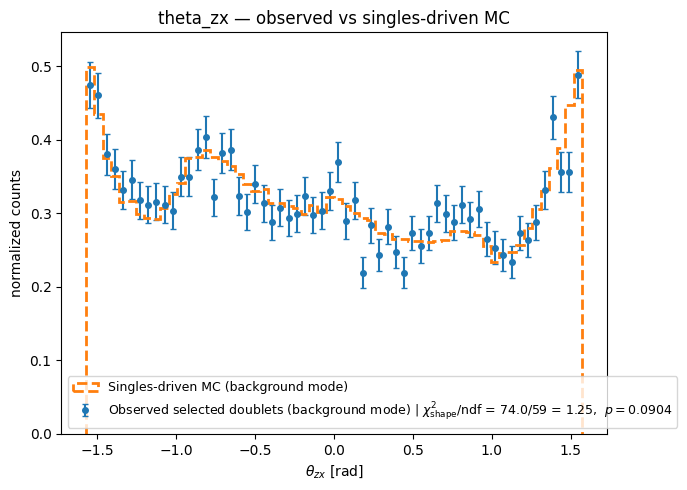

theta_zx — observed vs singles-driven MC
  shape-only diagnostic: $\chi^2_{\rm shape}$/ndf = 74.0/59 = 1.25,  $p = 0.0904$
  absolute singles-normalized diagnostic: $D_{\rm Pois,abs}$/ndf = 18748.5/60 = 312.47,  $p < 10^{-300}$
  singles-based expected total = 1.53e+03
Saved: double_blip_figures/002_theta_zy_observed_vs_singles-driven_MC.png


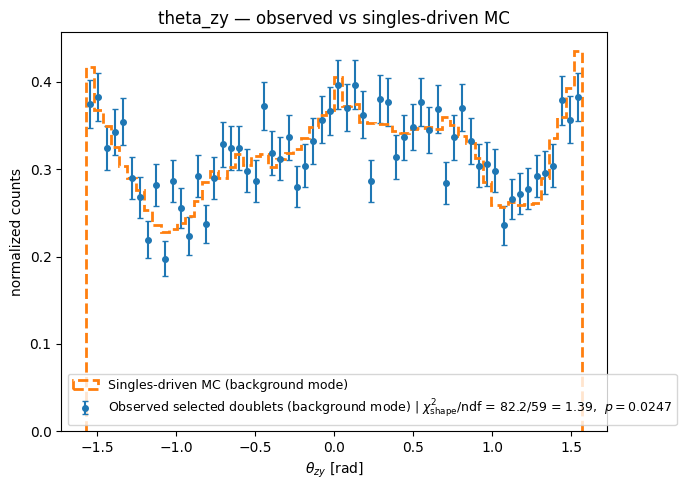

theta_zy — observed vs singles-driven MC
  shape-only diagnostic: $\chi^2_{\rm shape}$/ndf = 82.2/59 = 1.39,  $p = 0.0247$
  absolute singles-normalized diagnostic: $D_{\rm Pois,abs}$/ndf = 18756.0/60 = 312.60,  $p < 10^{-300}$
  singles-based expected total = 1.53e+03
Saved: double_blip_figures/003_theta_z_observed_vs_singles-driven_MC.png


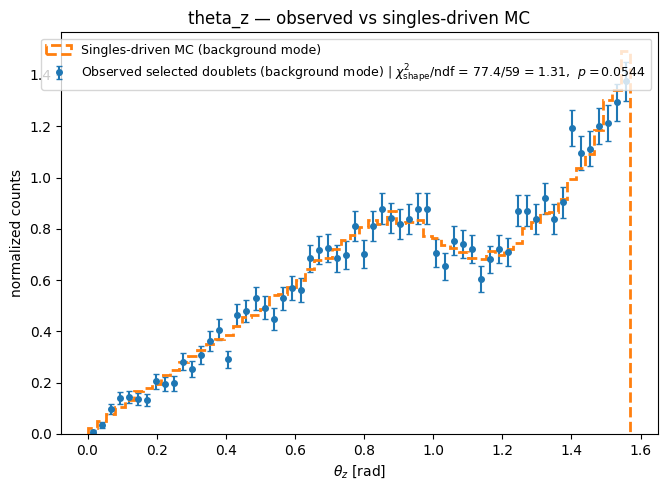

theta_z — observed vs singles-driven MC
  shape-only diagnostic: $\chi^2_{\rm shape}$/ndf = 77.4/59 = 1.31,  $p = 0.0544$
  absolute singles-normalized diagnostic: $D_{\rm Pois,abs}$/ndf = 18752.0/60 = 312.53,  $p < 10^{-300}$
  singles-based expected total = 1.53e+03


In [7]:
# Main angular comparisons

overlay_hist_simple(
    obs_doublets["theta_zx"], singles_mc["theta_zx"],
    OBS_LABEL, MC_LABEL,
    title="theta_zx — observed vs singles-driven MC",
    xlabel=r"$\theta_{zx}$ [rad]",
    bins=60,
    model_expected_total=EXPECTED_SINGLES_MC_VISIBLE,
)

overlay_hist_simple(
    obs_doublets["theta_zy"], singles_mc["theta_zy"],
    OBS_LABEL, MC_LABEL,
    title="theta_zy — observed vs singles-driven MC",
    xlabel=r"$\theta_{zy}$ [rad]",
    bins=60,
    model_expected_total=EXPECTED_SINGLES_MC_VISIBLE,
)

overlay_hist_simple(
    obs_doublets["theta_z"], singles_mc["theta_z"],
    OBS_LABEL, MC_LABEL,
    title="theta_z — observed vs singles-driven MC",
    xlabel=r"$\theta_z$ [rad]",
    bins=60,
    model_expected_total=EXPECTED_SINGLES_MC_VISIBLE,
)


## 7. Cluster-property comparisons

Saved: double_blip_figures/004_Total_cluster_size_npts0_npts1_observed_vs_singles-driven_MC.png


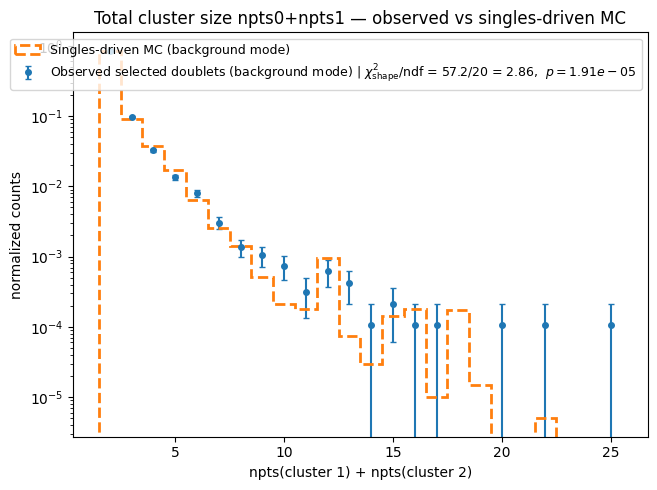

Total cluster size npts0+npts1 — observed vs singles-driven MC
  shape-only diagnostic: $\chi^2_{\rm shape}$/ndf = 57.2/20 = 2.86,  $p = 1.91e-05$
  absolute singles-normalized diagnostic: $D_{\rm Pois,abs}$/ndf = n/a, p = n/a
  singles-based expected total = 1.53e+03
Saved: double_blip_figures/005_Pair_energy_charge_sum_observed_vs_singles-driven_MC.png


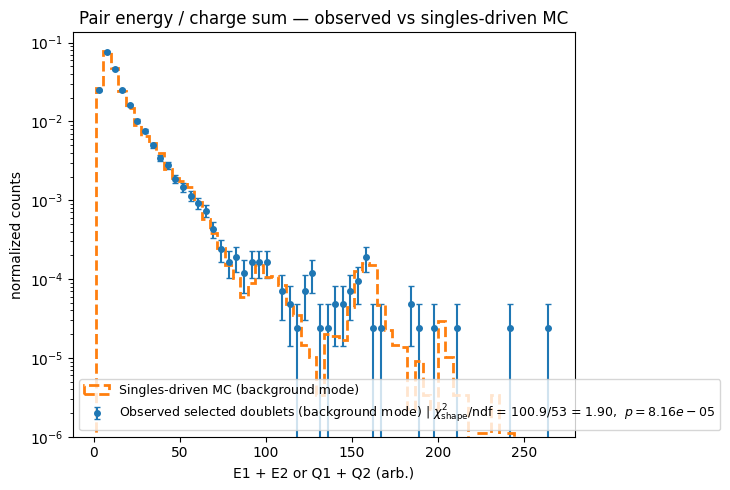

Pair energy / charge sum — observed vs singles-driven MC
  shape-only diagnostic: $\chi^2_{\rm shape}$/ndf = 100.9/53 = 1.90,  $p = 8.16e-05$
  absolute singles-normalized diagnostic: $D_{\rm Pois,abs}$/ndf = n/a, p = n/a
  singles-based expected total = 1.53e+03
Saved: double_blip_figures/006_Absolute_energy_charge_difference_observed_vs_singles-driven_MC.png


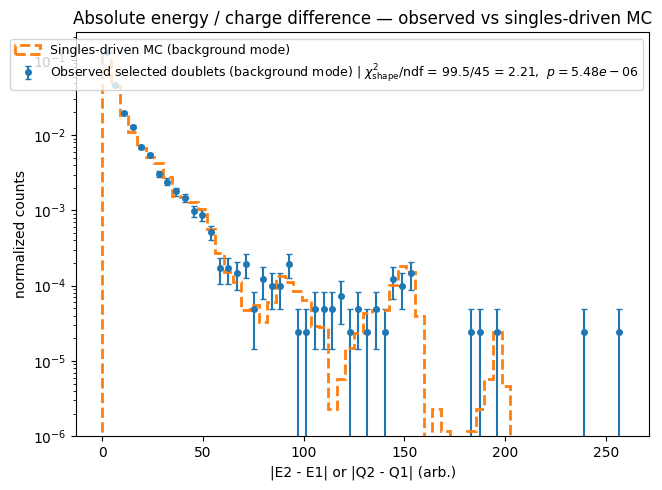

Absolute energy / charge difference — observed vs singles-driven MC
  shape-only diagnostic: $\chi^2_{\rm shape}$/ndf = 99.5/45 = 2.21,  $p = 5.48e-06$
  absolute singles-normalized diagnostic: $D_{\rm Pois,abs}$/ndf = n/a, p = n/a
  singles-based expected total = 1.53e+03


In [8]:
# Cluster-property comparisons

obs_total_npts = obs_doublets["npts0"] + obs_doublets["npts1"]
mc_total_npts = singles_mc["npts0"] + singles_mc["npts1"]
npts_bins = integer_sum_bins(obs_total_npts, mc_total_npts)

overlay_hist_simple(
    obs_total_npts.astype(int),
    mc_total_npts.astype(int),
    OBS_LABEL, MC_LABEL,
    title="Total cluster size npts0+npts1 — observed vs singles-driven MC",
    xlabel="npts(cluster 1) + npts(cluster 2)",
    bins=npts_bins,
    density=True,
    model_expected_total=EXPECTED_SINGLES_MC_VISIBLE,
    yscale="log",
)

if np.isfinite(obs_doublets["esum"]).sum() > 0 and np.isfinite(singles_mc["esum"]).sum() > 0:
    overlay_hist_simple(
        obs_doublets["esum"], singles_mc["esum"],
        OBS_LABEL, MC_LABEL,
        title="Pair energy / charge sum — observed vs singles-driven MC",
        xlabel="E1 + E2 or Q1 + Q2 (arb.)",
        bins=60,
        density=True,
        model_expected_total=EXPECTED_SINGLES_MC_VISIBLE,
        yscale="log",
    )

    overlay_hist_simple(
        obs_doublets["eabsdiff"], singles_mc["eabsdiff"],
        OBS_LABEL, MC_LABEL,
        title="Absolute energy / charge difference — observed vs singles-driven MC",
        xlabel="|E2 - E1| or |Q2 - Q1| (arb.)",
        bins=60,
        density=True,
        model_expected_total=EXPECTED_SINGLES_MC_VISIBLE,
        yscale="log",
    )
else:
    print("No usable per-cluster energy / charge field found; skipping energy/charge plots.")


## 8. Circular ROI diagnostic

Saved: double_blip_figures/007_Projected_angle_space_circular_ROI_diagnostic.png


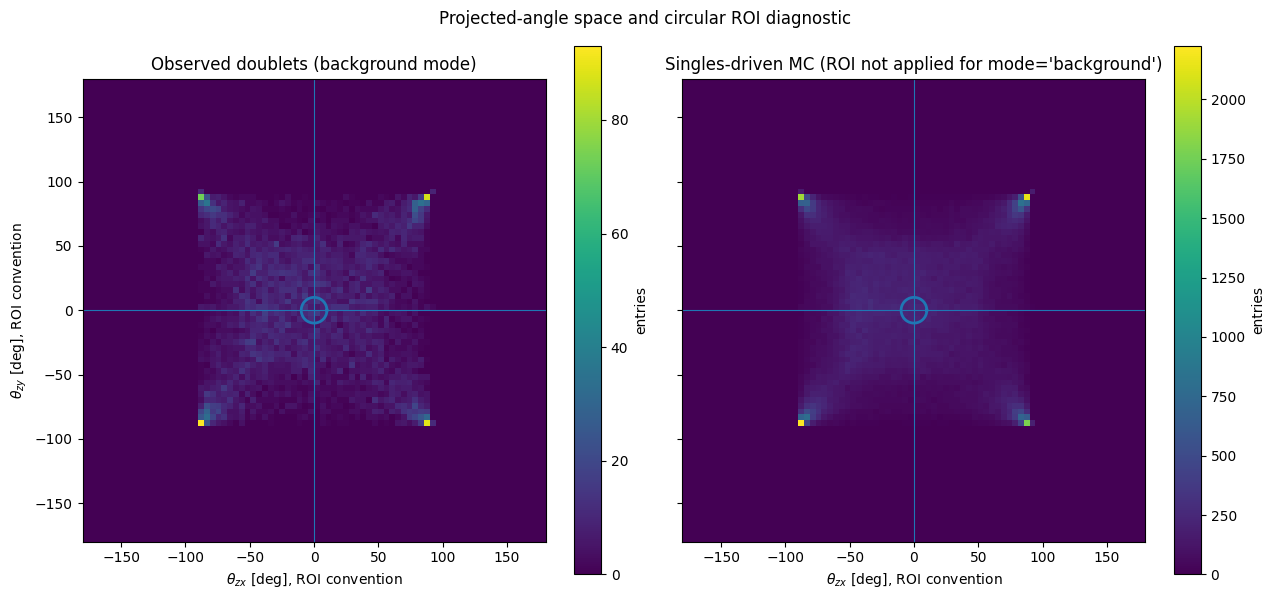

In [9]:
# Circular ROI diagnostic

if ROI_CONFIG is not None:
    plot_circular_roi_diagnostic(
        obs_doublets,
        singles_mc,
        ROI_CONFIG,
        blinding_mode=BLINDING_MODE,
        roi_applies_to_singles_mc=ROI_APPLIES_TO_SINGLES_MC,
    )
else:
    print("No circular ROI config found in the public mask; skipping ROI diagnostic.")
